In [164]:
import pandas as pd
import numpy as np

df_final = pd.read_csv("/Users/mangalyaphaye/Desktop/suvira_intelligence/data/FINAL_sentiment+macro.csv")

df_final["date"] = pd.to_datetime(df_final["date"])

# STEP 1: Work on FULL dataset first
urea_df_full = urea_df.copy()

# STEP 2: Create features BEFORE split
urea_df_full["lag_price"] = urea_df_full["price_usd_per_ton"].shift(1)
urea_df_full["price_change"] = urea_df_full["price_usd_per_ton"].diff()

# STEP 3: Drop NA after feature creation
urea_df_full = urea_df_full.dropna()

# STEP 4: Now split
train = urea_df_full.loc[urea_df_full.index <= "2025-08-01"].copy()
test = urea_df_full.loc[
    (urea_df_full.index >= "2025-09-01") &
    (urea_df_full.index <= "2025-12-01")
].copy()

# STEP 5: Define features
features = [
    "sentiment_score",
    "lag_price",
    "price_change",
    "crude_oil_price",
    "natural_gas_price"
]

target = "price_usd_per_ton"

# STEP 6: Final split
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# DEBUG
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (67, 5)
Test: (4, 5)


In [165]:
features = [
    "sentiment_score",
    "lag_price",
    "price_change",
    "crude_oil_price",
    "natural_gas_price"
]

target = "price_usd_per_ton"

train_full = train.copy()
test_full = test.copy()

for df_temp in [train_full, test_full]:
    df_temp["lag_price"] = df_temp["price_usd_per_ton"].shift(1)
    df_temp["price_change"] = df_temp["price_usd_per_ton"].diff()

train_full = train_full.dropna()

test_full["lag_price"] = test_full["lag_price"].fillna(method="bfill")
test_full["price_change"] = test_full["price_change"].fillna(0)

y_train = train_full[target]
y_test = test_full[target]

X_train = train_full[features]
X_test = test_full[features]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (66, 5)
X_test shape: (4, 5)
y_train shape: (66,)
y_test shape: (4,)


/var/folders/9s/w7j8ywnj0f7445fjtfdm26j00000gn/T/ipykernel_74750/3904015197.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_full["lag_price"] = test_full["lag_price"].fillna(method="bfill")


In [166]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False, maxiter=500)

print(model_fit.summary())

/Users/mangalyaphaye/.pyenv/versions/suvira-env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/mangalyaphaye/.pyenv/versions/suvira-env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                    price_usd_per_ton   No. Observations:                   66
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                 401.926
Date:                              Fri, 22 May 2026   AIC                           -779.853
Time:                                      02:29:52   BIC                           -760.202
Sample:                                  03-01-2020   HQIC                          -772.861
                                       - 08-01-2025                                         
Covariance Type:                                opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
sentiment_score   -9.546e-14   1.31e-07  -7.31e-07      1.000   -2.56e-07    2.56e-0

In [167]:
forecast_obj = model_fit.get_prediction(
    start=0,
    end=len(y_test) - 1,
    exog=X_test
)

forecast = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

forecast.index = y_test.index
conf_int.index = y_test.index

print(forecast)

date
2025-09-01    243.795889
2025-10-01    248.269399
2025-11-01    245.397996
2025-12-01    231.922041
Name: predicted_mean, dtype: float64


In [168]:
###test
print(len(forecast), len(y_test))

4 4


MAE: 189.27
RMSE: 190.54
MAPE (%): 43.71


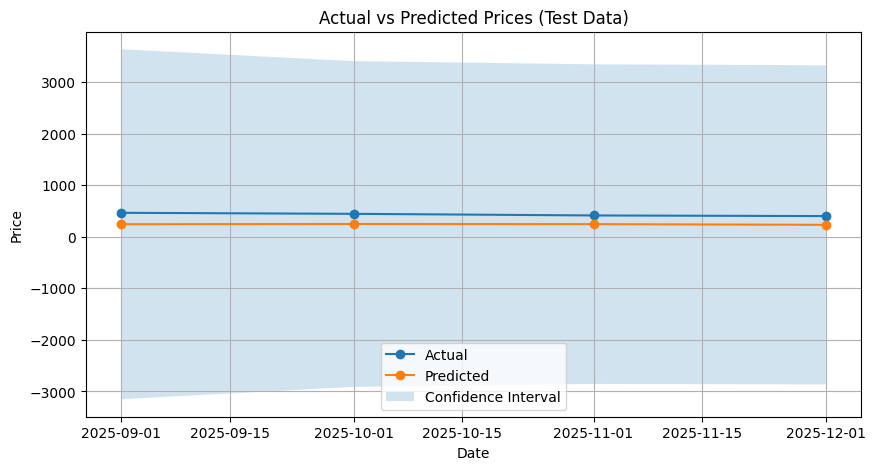

In [169]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Proper alignment (FINAL FIX)
y_test_aligned = y_test.copy()
forecast_aligned = forecast.copy()

# Ensure same length
min_len = min(len(y_test_aligned), len(forecast_aligned))
y_test_aligned = y_test_aligned.iloc[:min_len]
forecast_aligned = forecast_aligned.iloc[:min_len]

# Ensure same index (CRITICAL)
forecast_aligned.index = y_test_aligned.index

# Evaluation
mae = mean_absolute_error(y_test_aligned, forecast_aligned)
rmse = np.sqrt(mean_squared_error(y_test_aligned, forecast_aligned))
mape = np.mean(np.abs((y_test_aligned - forecast_aligned) / y_test_aligned)) * 100

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE (%):", round(mape, 2))

# Plot
plt.figure(figsize=(10,5))

plt.plot(y_test_aligned, label="Actual", marker='o')
plt.plot(forecast_aligned, label="Predicted", marker='o')

# Confidence interval
conf_int = conf_int.iloc[:min_len]
conf_int.index = y_test_aligned.index

plt.fill_between(
    y_test_aligned.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Actual vs Predicted Prices (Test Data)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

In [ ]:
#BELOW CODE FOR DOWNLOADING AND MERGING MACRO FREATURES.

In [113]:
!pip install yfinance

  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 3.2 MB/s eta 0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 13.7 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 8.8 MB/s eta 0:00:00
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [117]:
#extracted dat of crude oil adn natural gas prices from yahoo finance website. (MACRO DRIVERS) [MONTHLY]
import yfinance as yf

# Download Crude Oil (Brent)
oil = yf.download("BZ=F", start="2020-01-01", end="2026-05-01", interval="1mo")

# Download Natural Gas
gas = yf.download("NG=F", start="2020-01-01", end="2026-05-01", interval="1mo")

# Reset index
oil = oil.reset_index()
gas = gas.reset_index()

# Keep only Date and Close
oil = oil[["Date", "Close"]]
gas = gas[["Date", "Close"]]

# Rename columns
oil.columns = ["date", "crude_oil_price"]
gas.columns = ["date", "natural_gas_price"]

# Convert date format
oil["date"] = oil["date"].dt.strftime("%Y-%m-01")
gas["date"] = gas["date"].dt.strftime("%Y-%m-01")

oil.head(), gas.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


(         date  crude_oil_price
 0  2020-01-01        58.160000
 1  2020-02-01        50.520000
 2  2020-04-01        25.270000
 3  2020-05-01        35.330002
 4  2020-06-01        41.150002,
          date  natural_gas_price
 0  2020-01-01              1.841
 1  2020-02-01              1.684
 2  2020-04-01              1.949
 3  2020-05-01              1.849
 4  2020-06-01              1.751)

In [118]:
oil.to_csv("crude_oil_monthly.csv", index=False)
gas.to_csv("natural_gas_monthly.csv", index=False)

In [119]:
#missing data: crude oil
# Convert to datetime if not already
oil["date"] = pd.to_datetime(oil["date"])

# Create full expected timeline
full_dates = pd.date_range(start=oil["date"].min(), end=oil["date"].max(), freq="MS")

# Find missing dates
missing_dates = full_dates.difference(oil["date"])

print("Missing dates in oil data:")
print(missing_dates)

Missing dates in oil data:
DatetimeIndex(['2020-03-01', '2020-11-01', '2021-08-01', '2022-05-01',
               '2023-01-01', '2023-10-01', '2024-09-01', '2024-12-01',
               '2025-06-01', '2026-02-01', '2026-03-01'],
              dtype='datetime64[ns]', freq=None)


In [120]:
#missing data: crude oil
gas["date"] = pd.to_datetime(gas["date"])

full_dates_gas = pd.date_range(start=gas["date"].min(), end=gas["date"].max(), freq="MS")

missing_dates_gas = full_dates_gas.difference(gas["date"])

print("Missing dates in gas data:")
print(missing_dates_gas)

Missing dates in gas data:
DatetimeIndex(['2020-03-01', '2020-11-01', '2021-08-01', '2022-05-01',
               '2023-01-01', '2023-10-01', '2024-09-01', '2024-12-01',
               '2025-06-01', '2026-02-01', '2026-03-01'],
              dtype='datetime64[ns]', freq=None)


In [121]:
#extracted dat of crude oil adn natural gas prices from yahoo finance website. (MACRO DRIVERS) [DAILY due to missing dataaaa. aaa.]
import yfinance as yf

# Download Crude Oil (Brent)
oil = yf.download("BZ=F", start="2020-01-01", end="2026-05-01", interval="1d")

# Download Natural Gas
gas = yf.download("NG=F", start="2020-01-01", end="2026-05-01", interval="1d")

# Reset index
oil = oil.reset_index()
gas = gas.reset_index()

# Keep only Date and Close
oil = oil[["Date", "Close"]]
gas = gas[["Date", "Close"]]

# Rename columns
oil.columns = ["date", "crude_oil_price"]
gas.columns = ["date", "natural_gas_price"]

oil.head(), gas.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


(        date  crude_oil_price
 0 2020-01-02        66.250000
 1 2020-01-03        68.599998
 2 2020-01-06        68.910004
 3 2020-01-07        68.269997
 4 2020-01-08        65.440002,
         date  natural_gas_price
 0 2020-01-02              2.122
 1 2020-01-03              2.130
 2 2020-01-06              2.135
 3 2020-01-07              2.162
 4 2020-01-08              2.141)

In [122]:
oil.to_csv("crude_oil_daily.csv", index=False)
gas.to_csv("natural_gas_daily.csv", index=False)

In [124]:
#converted daily to monthly
oil["date"] = pd.to_datetime(oil["date"])
gas["date"] = pd.to_datetime(gas["date"])

oil = oil.set_index("date").resample("MS").mean().reset_index()
gas = gas.set_index("date").resample("MS").mean().reset_index()

In [129]:
print(oil.head(77))
print(gas.head())

         date  crude_oil_price
0  2020-01-01        63.600000
1  2020-02-01        55.362105
2  2020-03-01        33.729091
3  2020-04-01        26.631429
4  2020-05-01        32.256000
..        ...              ...
71 2025-12-01        61.628636
72 2026-01-01        64.765499
73 2026-02-01        69.406843
74 2026-03-01        99.599546
75 2026-04-01       102.464286

[76 rows x 2 columns]
        date  natural_gas_price
0 2020-01-01           2.029952
1 2020-02-01           1.843421
2 2020-03-01           1.731182
3 2020-04-01           1.759333
4 2020-05-01           1.809150


In [127]:
oil.shape

(76, 2)

In [130]:
#merged oil and gas prices
macro = pd.merge(oil, gas, on="date", how="inner")
print(macro.head())

        date  crude_oil_price  natural_gas_price
0 2020-01-01        63.600000           2.029952
1 2020-02-01        55.362105           1.843421
2 2020-03-01        33.729091           1.731182
3 2020-04-01        26.631429           1.759333
4 2020-05-01        32.256000           1.809150


In [131]:
#merged final dataset
df["date"] = pd.to_datetime(df["date"])
macro["date"] = pd.to_datetime(macro["date"])

df_final = pd.merge(df, macro, on="date", how="left")

print(df_final.head())

        date        netWgt      fobvalue  price_usd_per_ton     chemical  \
0 2020-01-01  1.449699e+08  5.501491e+07         379.491888  Acetic Acid   
1 2020-01-01  2.888552e+07  2.150078e+07         744.344399     Formates   
2 2020-01-01  2.820466e+09  6.749782e+08         239.314451          KCL   
3 2020-01-01  3.188438e+07  1.162156e+07         364.490829          PAC   
4 2020-01-01  1.650663e+09  8.968455e+07          54.332438      Sulphur   

   sentiment_score  crude_oil_price  natural_gas_price  
0        -0.025092             63.6           2.029952  
1         0.090143             63.6           2.029952  
2         0.046399             63.6           2.029952  
3         0.019732             63.6           2.029952  
4        -0.068796             63.6           2.029952  


In [132]:
df_final.shape

(592, 8)

In [ ]:
#downloaded the FINAL ds with macro+sentiment

In [133]:
df_final.to_csv("FINAL_sentiment+macro.csv", index=False)